In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import xgboost as xgb
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

# Charger les données
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print("=== DATASET TITANIC ===")
print(f"Train : {train.shape}")
print(f"Test  : {test.shape}")

print("\n=== APERÇU ===")
print(train.head())

print("\n=== INFOS ===")
print(train.info())

print("\n=== STATISTIQUES ===")
print(train.describe())

print("\n=== VALEURS MANQUANTES ===")
print(train.isnull().sum())

=== DATASET TITANIC ===
Train : (891, 12)
Test  : (418, 11)

=== APERÇU ===
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1

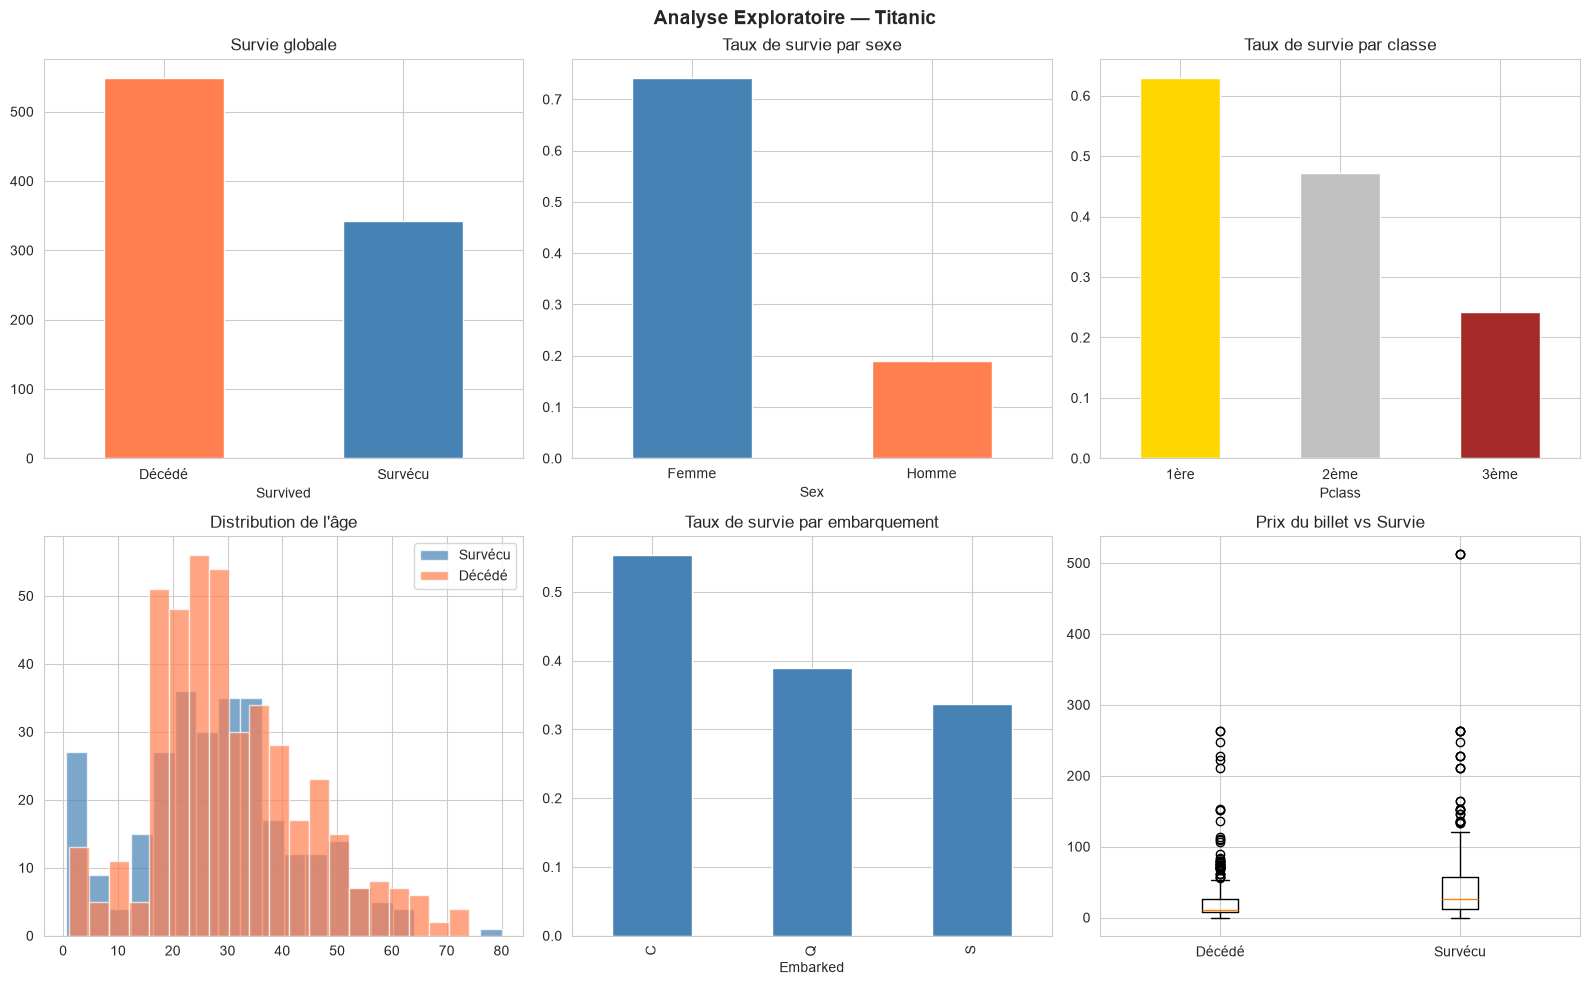

Observations clés :
  Taux survie global : 38.38%
  Taux survie femmes : 74.20%
  Taux survie hommes : 18.89%
  Taux survie 1ère classe : 62.96%
  Taux survie 3ème classe : 24.24%


In [2]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Taux de survie global
train["Survived"].value_counts().plot(kind="bar", ax=axes[0,0], 
                                       color=["coral", "steelblue"])
axes[0,0].set_title("Survie globale")
axes[0,0].set_xticklabels(["Décédé", "Survécu"], rotation=0)

# 2. Survie par sexe
train.groupby("Sex")["Survived"].mean().plot(kind="bar", ax=axes[0,1],
                                              color=["steelblue", "coral"])
axes[0,1].set_title("Taux de survie par sexe")
axes[0,1].set_xticklabels(["Femme", "Homme"], rotation=0)

# 3. Survie par classe
train.groupby("Pclass")["Survived"].mean().plot(kind="bar", ax=axes[0,2],
                                                 color=["gold", "silver", "brown"])
axes[0,2].set_title("Taux de survie par classe")
axes[0,2].set_xticklabels(["1ère", "2ème", "3ème"], rotation=0)

# 4. Distribution de l'âge
axes[1,0].hist(train[train["Survived"]==1]["Age"].dropna(), 
               bins=20, alpha=0.7, color="steelblue", label="Survécu")
axes[1,0].hist(train[train["Survived"]==0]["Age"].dropna(), 
               bins=20, alpha=0.7, color="coral", label="Décédé")
axes[1,0].set_title("Distribution de l'âge")
axes[1,0].legend()

# 5. Survie par port d'embarquement
train.groupby("Embarked")["Survived"].mean().plot(kind="bar", ax=axes[1,1],
                                                   color="steelblue")
axes[1,1].set_title("Taux de survie par embarquement")

# 6. Fare vs Survie
axes[1,2].boxplot([train[train["Survived"]==0]["Fare"].dropna(),
                   train[train["Survived"]==1]["Fare"].dropna()])
axes[1,2].set_xticklabels(["Décédé", "Survécu"])
axes[1,2].set_title("Prix du billet vs Survie")

plt.suptitle("Analyse Exploratoire — Titanic", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("Observations clés :")
print(f"  Taux survie global : {train['Survived'].mean():.2%}")
print(f"  Taux survie femmes : {train[train['Sex']=='female']['Survived'].mean():.2%}")
print(f"  Taux survie hommes : {train[train['Sex']=='male']['Survived'].mean():.2%}")
print(f"  Taux survie 1ère classe : {train[train['Pclass']==1]['Survived'].mean():.2%}")
print(f"  Taux survie 3ème classe : {train[train['Pclass']==3]['Survived'].mean():.2%}")

In [3]:
def preprocess(df, is_train=True):
    data = df.copy()
    
    # 1. Title depuis le nom
    data["Title"] = data["Name"].str.extract(r" ([A-Za-z]+)\.")
    data["Title"] = data["Title"].replace(
        ["Lady","Countess","Capt","Col","Don","Dr","Major","Rev","Sir","Jonkheer","Dona"], "Rare"
    )
    data["Title"] = data["Title"].replace("Mlle", "Miss")
    data["Title"] = data["Title"].replace("Ms", "Miss")
    data["Title"] = data["Title"].replace("Mme", "Mrs")
    
    # 2. Family Size
    data["FamilySize"] = data["SibSp"] + data["Parch"] + 1
    data["IsAlone"] = (data["FamilySize"] == 1).astype(int)
    
    # 3. Age — imputation par médiane par Title
    data["Age"] = data.groupby("Title")["Age"].transform(
        lambda x: x.fillna(x.median())
    )
    
    # 4. Fare — imputation par médiane
    data["Fare"] = data["Fare"].fillna(data["Fare"].median())
    
    # 5. Embarked — imputation par mode
    data["Embarked"] = data["Embarked"].fillna(data["Embarked"].mode()[0])
    
    # 6. Fare bins
    data["FareBin"] = pd.qcut(data["Fare"], 4, labels=False)
    
    # 7. Age bins
    data["AgeBin"] = pd.cut(data["Age"], bins=[0,12,18,35,60,100], 
                             labels=False)
    
    # 8. Encodage
    data["Sex"] = (data["Sex"] == "female").astype(int)
    data["Embarked"] = data["Embarked"].map({"S": 0, "C": 1, "Q": 2})
    data["Title"] = data["Title"].map(
        {"Mr": 0, "Miss": 1, "Mrs": 2, "Master": 3, "Rare": 4}
    ).fillna(0)
    
    # Features finales
    features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare",
                "Embarked", "Title", "FamilySize", "IsAlone", 
                "FareBin", "AgeBin"]
    
    return data[features]

X = preprocess(train)
y = train["Survived"]
X_test_final = preprocess(test, is_train=False)

print("=== FEATURES APRÈS PREPROCESSING ===")
print(X.head())
print(f"\nShape train : {X.shape}")
print(f"Shape test  : {X_test_final.shape}")
print(f"\nValeurs manquantes : {X.isnull().sum().sum()}")

=== FEATURES APRÈS PREPROCESSING ===
   Pclass  Sex   Age  SibSp  Parch     Fare  Embarked  Title  FamilySize  \
0       3    0  22.0      1      0   7.2500         0      0           2   
1       1    1  38.0      1      0  71.2833         1      2           2   
2       3    1  26.0      0      0   7.9250         0      1           1   
3       1    1  35.0      1      0  53.1000         0      2           2   
4       3    0  35.0      0      0   8.0500         0      0           1   

   IsAlone  FareBin  AgeBin  
0        0        0       2  
1        0        3       3  
2        1        1       2  
3        0        3       2  
4        1        1       2  

Shape train : (891, 12)
Shape test  : (418, 12)

Valeurs manquantes : 0


=== COMPARAISON DES MODÈLES (CV 5-Fold) ===

Logistic Regression       → 0.8137 ± 0.0112
Random Forest             → 0.8159 ± 0.0081
Gradient Boosting         → 0.8361 ± 0.0105
XGBoost                   → 0.8114 ± 0.0156


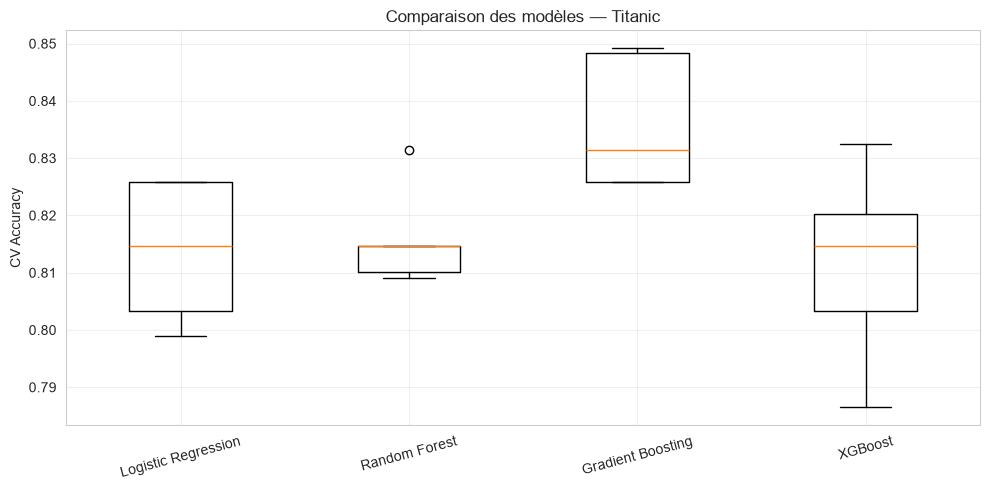


✅ Meilleur modèle : Gradient Boosting
   Score CV : 0.8361


In [4]:
from sklearn.model_selection import StratifiedKFold

# Comparer plusieurs modèles
modeles = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=200, random_state=42),
    "XGBoost":             xgb.XGBClassifier(n_estimators=200, random_state=42, 
                                              verbosity=0, eval_metric="logloss")
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("=== COMPARAISON DES MODÈLES (CV 5-Fold) ===\n")
resultats = {}
for nom, model in modeles.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")
    resultats[nom] = scores
    print(f"{nom:25s} → {scores.mean():.4f} ± {scores.std():.4f}")

# Visualisation
plt.figure(figsize=(10, 5))
plt.boxplot(resultats.values(), tick_labels=resultats.keys())
plt.title("Comparaison des modèles — Titanic")
plt.ylabel("CV Accuracy")
plt.xticks(rotation=15)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Meilleur modèle
best_nom = max(resultats, key=lambda k: resultats[k].mean())
print(f"\n✅ Meilleur modèle : {best_nom}")
print(f"   Score CV : {resultats[best_nom].mean():.4f}")

✅ Fichier submission.csv créé !

Aperçu :
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1
5          897         0
6          898         0
7          899         0
8          900         1
9          901         0

Total prédictions : 418
Survivants prédits : 149 (35.65%)


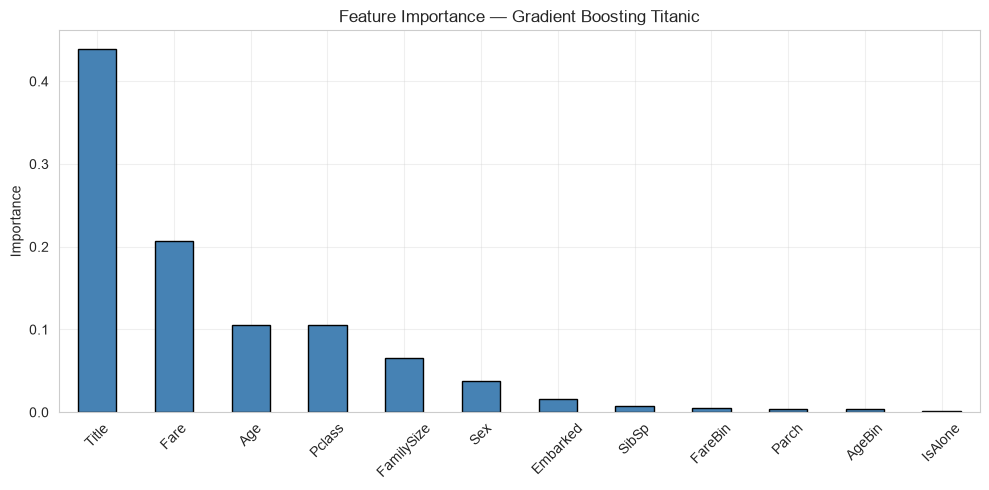


=== TOP FEATURES ===
  Title           : 0.4394
  Fare            : 0.2073
  Age             : 0.1058
  Pclass          : 0.1056
  FamilySize      : 0.0658
  Sex             : 0.0374
  Embarked        : 0.0159
  SibSp           : 0.0077
  FareBin         : 0.0055
  Parch           : 0.0041
  AgeBin          : 0.0037
  IsAlone         : 0.0017


In [5]:
# Entraîner le meilleur modèle sur tout le dataset
best_model = GradientBoostingClassifier(n_estimators=200, random_state=42)
best_model.fit(X, y)

# Prédictions sur le test
predictions = best_model.predict(X_test_final)

# Créer le fichier de soumission
submission = pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Survived": predictions
})

submission.to_csv("submission.csv", index=False)
print("✅ Fichier submission.csv créé !")
print(f"\nAperçu :")
print(submission.head(10))
print(f"\nTotal prédictions : {len(submission)}")
print(f"Survivants prédits : {predictions.sum()} ({predictions.mean():.2%})")

# Feature importance
importances = pd.Series(best_model.feature_importances_, 
                        index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
importances.plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Feature Importance — Gradient Boosting Titanic")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n=== TOP FEATURES ===")
for feat, imp in importances.items():
    print(f"  {feat:15s} : {imp:.4f}")